# Raw EEG Temporal Analysis

This notebook explores segmentation of EEG signals into fixed-length windows to analyze temporal structure and its effect on classification performance.

This includes:
- Window-based segmentation (2s, 5s, 10s)
- Welch-based band power extraction
- Comparison of classification performance across time scales 
-(Next) Temporal ablation analysis 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from pathlib import Path 

from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.base import clone

import os 

In [38]:
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"
RESULTS_DIR = PROJECT_ROOT / "results"
SEGMENTED_DATA_DIR = PROJECT_ROOT / "data" / "segmented_data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("SEGMENTED_DATA_DIR:", SEGMENTED_DATA_DIR)

PROJECT_ROOT: d:\eeg-mdd-classification
RAW_DATA_DIR: d:\eeg-mdd-classification\data\raw\nm000114
PROCESSED_DIR: d:\eeg-mdd-classification\data\processed_features
RESULTS_DIR: d:\eeg-mdd-classification\results
SEGMENTED_DATA_DIR: d:\eeg-mdd-classification\data\segmented_data


In [6]:
def get_eeg_file(subject_id: str, condition: str):
    """ Get the path to the EEG file for a given subject and condition.
    """
    return RAW_DATA_DIR / subject_id / "eeg" / f"{subject_id}_task-{condition}_eeg.edf"

def infer_label_from_subject(subject_id: str) -> int:
    """
    Infer the label (0 for healthy control, 1 for MDD) from the subject ID.
    """
    subject_upper = subject_id.upper()
    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1 
    else: 
        raise ValueError(f"Could not infer label from subject ID: {subject_id}")
    
def parse_condition_from_filename(filepath: Path) -> str:
    """
    Parse the condition (eyesClosed, eyesOpen, P300) from the filename.
    """
    name = filepath.name 
    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    else:
        raise ValueError(f"Could not parse condition from filename: {name}")
        
edf_files =sorted(RAW_DATA_DIR.glob("sub*/eeg/*.edf"))
        
rows = []
for filepath in edf_files:
    subject_id = filepath.parts[-3] 
    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": infer_label_from_subject(subject_id),
        "condition": parse_condition_from_filename(filepath),
        "filepath": str(filepath),
    })


# Create a DataFrame from the metadata
metadata_df = pd.DataFrame(rows)
metadata_df.head()        

,patient_id,recording_id,label,condition,filepath
0,sub-HS1,sub-HS1_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
1,sub-HS1,sub-HS1_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...
2,sub-HS1,sub-HS1_task-P300_eeg,0,P300,d:\eeg-mdd-classification\data\raw\nm000114\su...
3,sub-HS10,sub-HS10_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
4,sub-HS10,sub-HS10_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...


In [7]:
print("Shape:", metadata_df.shape)
print("\nUnique patients:", metadata_df["patient_id"].nunique())
print("\nClass counts:")
print(metadata_df["label"].value_counts())
print("\nCondition counts:")
print(metadata_df["condition"].value_counts())
print("\nRecordings per patient:")
print(metadata_df.groupby("patient_id").size().value_counts())

metadata_path = PROCESSED_DIR / "metadata.csv"
metadata_df.to_csv(metadata_path, index=False)
print("\nMetadata saved to:", metadata_path)

Shape: (181, 5)

Unique patients: 64

Class counts:
label
1    95
0    86
Name: count, dtype: int64

Condition counts:
condition
eyesOpen      62
P300          61
eyesClosed    58
Name: count, dtype: int64

Recordings per patient:
3    52
2    10
4     1
1     1
Name: count, dtype: int64

Metadata saved to: d:\eeg-mdd-classification\data\processed_features\metadata.csv


In [8]:
COMMON_CHANNELS = [
'EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 
 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 
 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'
]

print("Number of common channels:", len(COMMON_CHANNELS))


Number of common channels: 20


## SEGMENTATION

In [9]:
# test segmentation on one recording 

test_path = metadata_df.loc[0,"filepath"]
raw_test = mne.io.read_raw_edf(test_path, preload=True, verbose=False)

# keep only the common channels 
raw_test.pick(COMMON_CHANNELS)

# create 5-second windows 
epochs_test = mne.make_fixed_length_epochs(
    raw_test,
    duration=5.0,
    preload=True,
    overlap=0.0
)

print(epochs_test)
print("Number of windows:", len(epochs_test))
print("Epoch data shape:", epochs_test.get_data().shape)

Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 1280 original time points ...
0 bad epochs dropped
<Epochs | 60 events (all good), 0 – 4.996 s (baseline off), ~11.7 MiB, data loaded,
 '1': 60>
Number of windows: 60
Epoch data shape: (60, 20, 1280)


- 150 windows, recording was split into 150 chunkcs of 2 seconds each 
- 20 channels: matches standardized EEg channels
- 512 timepoints: confirms sampling rate ~256 Hz
- 1 recording -> 150 samples 

- very short time windows do not provide sufficient frequency resolution for stable band-power features

changed to chunks of 5 seconds 
- 60 windows- fewer because they are longer
- 20 channels
- 1280 timepoints



In [9]:
# Helper function to extract band-power features from each window and flatten into a feature vector

def extract_band_power_from_array(epoch_data, sfreq):
    """ 
    epoch_data: shape (n_channels, n_timepoints)
    sfreq: sampling frequency 
    returns: flatten feature vector
    """

    bands = {
        "delta": (1, 4),     # deep sleep
        "theta": (4, 8),     # drowsiness
        "alpha": (8, 13),    # relaxed 
        "beta":  (13, 30)    # active thinking
    }

    all_features = []

    for ch in epoch_data:
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            n_fft=min(len(ch), 256),   # use smaller n_fft for short windows
            n_per_seg=min(len(ch), 256),
            verbose=False
        )

        total_power = psd.sum()

        band_features = [
            (
                psd[(freqs >= fmin) & (freqs <= fmax)].mean() / total_power
                if total_power > 0 else 0 
            )
            for (fmin, fmax) in bands.values()
        ]

        all_features.append(band_features)

    return np.nan_to_num(np.array(all_features).flatten())



error: n_fft is not allows to be > n times
window length = 512 timepoints
welch tries to use default fft window larger than 512 - crash

fix: 
explicitly control the FFT size n_fft= min(len(ch), 256), n_per_seg = min(len(ch), 256)

In [11]:
# test on one window

epoch_array = epochs_test.get_data()[0]
sfreq = epochs_test.info["sfreq"]

features_test = extract_band_power_from_array(epoch_array, sfreq)
print("Extracted features shape:", features_test.shape)

Extracted features shape: (80,)


In [31]:
# Build segmented dataset from all recordings

def build_segmented_dataset(metadata_df, common_channels, window_sec=5.0):
    X_segments = []
    y_segments = []
    groups_segments = []
    condition_segments = []
    recording_segments = []

    for _, row in metadata_df.iterrows():
        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(common_channels)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            preload=True,
            overlap=0.0,
            verbose=False
        )

        epoch_data = epochs.get_data()
        sfreq = epochs.info["sfreq"]

        for i in range(len(epoch_data)):
            features = extract_band_power_from_array(epoch_data[i], sfreq)

            X_segments.append(features)
            y_segments.append(row["label"])
            groups_segments.append(row["patient_id"])
            condition_segments.append(row["condition"])
            recording_segments.append(f"{row['recording_id']}_seg{i}")

    X_segments = np.vstack(X_segments)
    y_segments = np.array(y_segments)
    groups_segments = np.array(groups_segments)

    segmented_df = pd.DataFrame({
        "recording_segment": recording_segments,
        "petient_id": groups_segments,
        "label": y_segments,
        "condition": condition_segments
    })

    return X_segments, y_segments, groups_segments, segmented_df


In [ ]:
X_seg, y_seg, groups_seg, segmented_df = build_segmented_dataset(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=5.0
)

print("Segmented X shape:", X_seg.shape)
print("Segmented y shape:", y_seg.shape)
print("Unique patients:", len(np.unique(groups_seg)))
print(segmented_df.head())

Segmented X shape: (14743, 80)
Segmented y shape: (14743,)
Unique patients: 64
                  recording_segment petient_id  label   condition
0  sub-HS1_task-eyesClosed_eeg_seg0    sub-HS1      0  eyesClosed
1  sub-HS1_task-eyesClosed_eeg_seg1    sub-HS1      0  eyesClosed
2  sub-HS1_task-eyesClosed_eeg_seg2    sub-HS1      0  eyesClosed
3  sub-HS1_task-eyesClosed_eeg_seg3    sub-HS1      0  eyesClosed
4  sub-HS1_task-eyesClosed_eeg_seg4    sub-HS1      0  eyesClosed


- 14,743 samples: each one = a 5-second EEG window
- 80 features: same feature space ( 20 channels x 4 bandds)
- 64 unique patients: grouping still intact

- 80X increase in data 

## Evaluate 

In [18]:
gkf = GroupKFold(n_splits=5)

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

In [ ]:
results_seg = cross_validate(
    pipeline_svm,
    X_seg,
    y_seg,
    groups=groups_seg,
    cv=gkf,
    scoring=["accuracy", "f1", "roc_auc"]
)

print("Segmented accuracy:", results_seg["test_accuracy"].mean())
print("Segmented F1-score:", results_seg["test_f1"].mean())
print("Segmented ROC-AUC:", results_seg["test_roc_auc"].mean()) 


Segmented accuracy: 0.7987627219303793
Segmented F1-score: 0.8125608191802302
Segmented ROC-AUC: 0.889488370026314


- Accuracy ~0.799
- F1 score: ~0.813
- ROC-AUC: ~ 0.889

Segmented EEG performs as well or better than full recordings. 
5-second EEG windows contain enough information to distinguish MDD vs Healthy. 
Local signal is informative.
signal is distributed over time. The discriminative features are not confined to a single moment-they appear repeatedly across the recording. 
- stronger roc-auc - better separation 



# Re-do with cache saving 

In [63]:
def save_segmented_data(X, y, groups, seg_df, window_sec, save_dir=SEGMENTED_DATA_DIR):
    save_dir.mkdir(parents=True, exist_ok=True)

    suffix = f"{int(window_sec)}sec"

    np.save(save_dir / f"X_seg_{suffix}.npy", X)
    np.save(save_dir / f"y_seg_{suffix}.npy", y)
    np.save(save_dir / f"groups_seg_{suffix}.npy", groups)
    seg_df.to_csv(save_dir / f"seg_df_{suffix}.csv", index=False)

In [64]:
def load_segmented_data(window_sec, save_dir=SEGMENTED_DATA_DIR):
    suffix = f"{int(window_sec)}sec"

    X = np.load(save_dir /  f"X_seg_{suffix}.npy")
    y = np.load(save_dir / f"y_seg_{suffix}.npy")
    groups = np.load(save_dir / f"groups_seg_{suffix}.npy")
    seg_df = pd.read_csv(save_dir / f"seg_df_{suffix}.csv")

    return X, y, groups, seg_df

In [49]:
def get_or_build_segmented_data(metadata_df, common_channels, window_sec, save_dir=SEGMENTED_DATA_DIR):
    suffix = f"{int(window_sec)}sec"
    X_path = save_dir / f"X_seg_{suffix}.npy"

    if X_path.exists():
        print(f"loading cached data for {window_sec}s...")
        return load_segmented_data(window_sec, save_dir=save_dir)
    
    print(f"Building segmented data for {window_sec}s...")
    X, y, groups, seg_df = build_segmented_dataset(
        metadata_df, 
        common_channels,
        window_sec=window_sec
    )

    save_segmented_data(X, y, groups, seg_df, window_sec)

    return X, y, groups, seg_df 

In [44]:
X_seg_5, y_seg_5, groups_seg_5, seg_df_5 = get_or_build_segmented_data(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=5.0
)

Building segmented data for 5.0s...


In [45]:
results_5 = cross_validate(
    pipeline_svm,
    X_seg_5,
    y_seg_5,    
    groups=groups_seg_5,
    cv=gkf,
    scoring=["accuracy", "f1", "roc_auc"]
)

print("Accuracy:", results_5["test_accuracy"].mean())
print("F1:", results_5["test_f1"].mean())
print("ROC AUC:", results_5["test_roc_auc"].mean()) 

Accuracy: 0.7987627219303793
F1: 0.8125608191802302
ROC AUC: 0.889488370026314


In [58]:
window_sizes = [5.0, 10.0]

results = []

for w in window_sizes:
    print(f"\n===Window: {w} sec ===")

    # load or build segmented data for this window size
    try:
        X, y, groups, _ = get_or_build_segmented_data(
         metadata_df,
         COMMON_CHANNELS, 
         window_sec=w
        )

        print("Data shape;", X.shape)

        # run cross-validation with SVM pipeline
        cv_results = cross_validate(
            pipeline_svm,
            X,
            y,
            groups=groups,
            cv=gkf,
            scoring=["accuracy", "f1", "roc_auc"]
        )

        # store results for this window size
        results.append({
            "window_sec": w,
            "accuracy": cv_results["test_accuracy"].mean(),
            "f1": cv_results["test_f1"].mean(),  
            "roc_auc": cv_results["test_roc_auc"].mean() 
        })

    except Exception as e:
        print(f"Failed for window {w}: {e}")

        results.append({
            "window_sec": w,
            "status": "failed",
            "n_samples": None,
            "accuracy": None,
            "f1": None,
            "roc_auc": None
    })


window_results_df = pd.DataFrame(results)
print(window_results_df)


===Window: 5.0 sec ===
loading cached data for 5.0s...
Data shape; (14743, 80)

===Window: 10.0 sec ===
loading cached data for 10.0s...
Data shape; (7339, 80)
   window_sec  accuracy        f1   roc_auc
0         5.0  0.798763  0.812561  0.889488
1        10.0  0.827231  0.844465  0.908115


### Interpretation:
Performance improves when increasing window size from 5 to 10 seconds, suggesting that depression-related EEG patterns are better captured over longer temporal windows. 

 ## position based ablation across 10-second windows 
    - segment each recording into 10-second windows
    - label each window by its order in the recording: segment 0, segment 1....
    - remove one segment position at a time across the dataset
    - rerun the model
    -compare performance to the unablated baseline 

In [68]:

# Build segmented dataset from all recordings

def build_segmented_dataset(metadata_df, common_channels, window_sec=5.0):
    X_segments = []
    y_segments = []
    groups_segments = []
    condition_segments = []
    recording_segments = []
    segmented_indices = []

    for _, row in metadata_df.iterrows():
        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(common_channels)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            preload=True,
            overlap=0.0,
            verbose=False
        )

        epoch_data = epochs.get_data()
        sfreq = epochs.info["sfreq"]

        for i in range(len(epoch_data)):
            features = extract_band_power_from_array(epoch_data[i], sfreq)

            X_segments.append(features)
            y_segments.append(row["label"])
            groups_segments.append(row["patient_id"])
            condition_segments.append(row["condition"])
            recording_segments.append(f"{row['recording_id']}_seg{i}")
            segmented_indices.append(i)

    X_segments = np.vstack(X_segments)
    y_segments = np.array(y_segments)
    groups_segments = np.array(groups_segments)

    segmented_df = pd.DataFrame({
        "recording_segment": recording_segments,
        "petient_id": groups_segments,
        "label": y_segments,
        "condition": condition_segments,
        "segment_idx": segmented_indices
    })

    return X_segments, y_segments, groups_segments, segmented_df

In [69]:
suffix = "10sec"

for fname in [
    f"X_seg_{suffix}.npy",
    f"y_seg_{suffix}.npy",
    f"groups_seg_{suffix}.npy",
    f"seg_df_{suffix}.csv",
]:
    path = SEGMENTED_DATA_DIR / fname
    if path.exists():
        path.unlink()
        print("Deleted:", path)

Deleted: d:\eeg-mdd-classification\data\segmented_data\X_seg_10sec.npy
Deleted: d:\eeg-mdd-classification\data\segmented_data\y_seg_10sec.npy
Deleted: d:\eeg-mdd-classification\data\segmented_data\groups_seg_10sec.npy
Deleted: d:\eeg-mdd-classification\data\segmented_data\seg_df_10sec.csv


In [70]:
X_seg_10, y_seg_10, groups_seg_10, seg_df_10 = get_or_build_segmented_data(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=10.0
)

print(seg_df_10.head())
print(seg_df_10["segment_idx"].describe())

Building segmented data for 10.0s...


KeyboardInterrupt: 

count    7339.000000

mean       22.717264

std        16.357041

min         0.000000

25%        10.000000

50%        20.000000

75%        32.000000

max        67.000000

Name: segment_idx, dtype: float64

In [ ]:
seg_df_10["segment_id"] = seg_df_10["segment_idx"].astype(int)

In [72]:
segment_counts = seg_df_10["segment_idx"].value_counts().sort_index()
segment_counts.head(10)

segment_idx
0    181
1    181
2    181
3    181
4    181
5    181
6    181
7    181
8    181
9    181
Name: count, dtype: int64

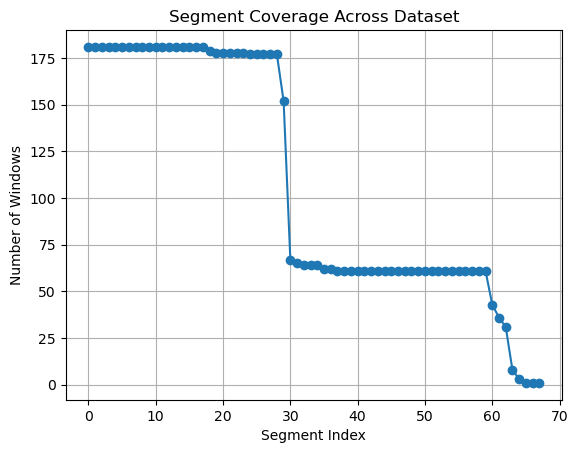

In [73]:
segment_counts.plot(marker="o")
plt.xlabel("Segment Index")
plt.ylabel("Number of Windows")
plt.title("Segment Coverage Across Dataset")
plt.grid(True)
plt.show()

1. stable region 
    - segment 0 -> 28 
    - ~180 samples per segment 
    - most reliable region

2. drop off region
    - around 29-30
    - sudden drop from ~ 180 -> ~65

3. Plateau
    - ~30 -> ~58
    - ~60 samples per segment 
    - medium reliability

4. Collapse region 
    - ~60+ 
    - Rapid drop near 0
    - noisy 
    - underepresented


Approach: restrict ablation range to stable region.

In [87]:
def run_temporal_ablation(
    X_seg,
    y_seg,
    groups_seg,
    seg_df,
    model,
    gkf,
    valid_segments=None
):
    """
    Remove one segment index at a time and evaluate the change in performance.
    
    Parameters
    ----------
    X_seg: np.ndarray
        Segmented feature matrix
    y_seg: np.ndarray
        Segmented target vector
    groups_seg: np.ndarray
        Segmented group labels
    seg_df: pd.DataFrame
        DataFrame containing segment information
    model: sklearn estimator
        The machine learning model to evaluate
    gkf: sklearn cross-validator
        Group k-fold cross-validator
    valid_segments: list, or None
        List of valid segment indices to consider

    Returns
    -------
    baseline_ablation_df: pd.DataFrame
        DataFrame containing baseline performance metrics
    ablation_results_df: pd.DataFrame
        DataFrame containing ablation results for each removed segment
    """

    if "segment_idx" not in seg_df.columns:
        raise ValueError ("seg_df must contain a 'segment_idx' column")
    
    seg_df = seg_df.copy()
    seg_df["segment_idx"] = seg_df["segment_idx"].astype(int)

    baseline = cross_validate(
        model,
        X_seg,
        y_seg,
        groups=groups_seg,
        cv=gkf,
        scoring=["accuracy", "f1", "roc_auc"]
    )

   
    baseline_acc = baseline["test_accuracy"].mean(),
    baseline_f1 =  baseline["test_f1"].mean(),
    baseline_auc = baseline["test_roc_auc"].mean()
    

    if valid_segments is None:
        valid_segments = sorted(seg_df["segment_idx"].unique())

    results = []

    for seg_idx in valid_segments:
        keep_mask = seg_df["segment_idx"] != seg_idx

        X_ablate = X_seg[keep_mask]
        y_ablate = y_seg[keep_mask]
        groups_ablate = groups_seg[keep_mask]

        cv_results = cross_validate(
            model,
            X_ablate,
            y_ablate,
            groups=groups_ablate,   
            cv=gkf,
            scoring=["accuracy", "f1", "roc_auc"]
        )
        
        acc = cv_results["test_accuracy"].mean()
        f1 = cv_results["test_f1"].mean()
        auc = cv_results["test_roc_auc"].mean()

        results.append({
            "ablated_segment": seg_idx,
            "n_samples_remaining": X_ablate.shape[0],
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc,
            "delta_accuracy": acc - baseline_acc,
            "delta_f1": f1 - baseline_f1,
            "delta_roc_auc": auc - baseline_auc
        })

    baseline_df = pd.DataFrame([{
        "ablated_segment": "baseline",
        "n_samples_remaining": X_seg.shape[0],
        "accuracy": baseline_acc,
        "f1": baseline_f1,
        "roc_auc": baseline_auc,
        "delta_accuracy": 0.0,
        "delta_f1": 0.0,
        "delta_roc_auc": 0.0
    }])

    ablation_results_df = pd.DataFrame(results)

    return baseline_df, ablation_results_df

In [88]:
VALID_SEGMENTS = range(0,30)

baseline_ablation_df, ablation_results_df = run_temporal_ablation(
    X_seg_10,
    y_seg_10,
    groups_seg_10,
    seg_df_10,
    model=pipeline_svm,
    gkf=gkf,
    valid_segments=VALID_SEGMENTS
)

In [89]:
print(ablation_results_df.columns)
print(ablation_results_df.head())
print(list(VALID_SEGMENTS)[:10])

Index(['ablated_segment', 'n_samples_remaining', 'accuracy', 'f1', 'roc_auc',
       'delta_accuracy', 'delta_f1', 'delta_roc_auc'],
      dtype='object')
   ablated_segment  n_samples_remaining  accuracy        f1   roc_auc  \
0                0                 7158  0.825841  0.842266  0.905412   
1                1                 7158  0.825866  0.842548  0.904435   
2                2                 7158  0.824530  0.841551  0.906052   
3                3                 7158  0.823974  0.840201  0.905304   
4                4                 7158  0.822984  0.839972  0.904258   

             delta_accuracy                  delta_f1  delta_roc_auc  
0  [-0.0013897422981976604]  [-0.0021997703686277292]      -0.002703  
1  [-0.0013648081445213345]   [-0.001917569233323979]      -0.003680  
2  [-0.0027008672253011623]   [-0.002914450777424249]      -0.002064  
3   [-0.003257480493761733]   [-0.004264793636172826]      -0.002812  
4   [-0.004247293652210105]   [-0.00449324072282197

In [93]:
ablation_results_df["delta_accuracy"] = ablation_results_df["delta_accuracy"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x
)

ablation_results_df["delta_f1"] = ablation_results_df["delta_f1"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x
)

ablation_results_df["delta_roc_auc"] = ablation_results_df["delta_roc_auc"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x  
)


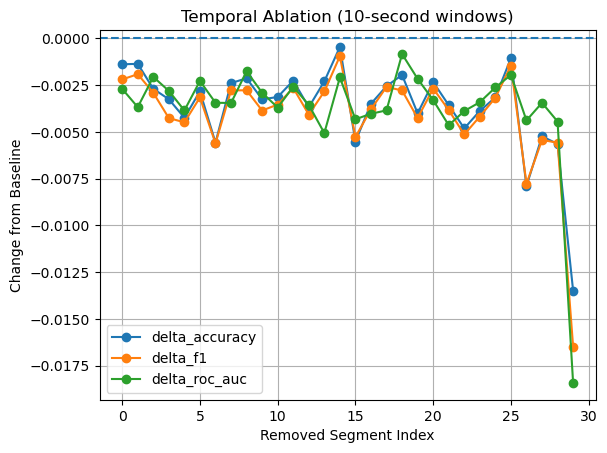

In [94]:
ablation_results_df.plot(
    x="ablated_segment",
    y=["delta_accuracy", "delta_f1", "delta_roc_auc"],
    marker='o'
)

plt.axhline(0, linestyle="--")
plt.xlabel("Removed Segment Index")
plt.ylabel("Change from Baseline")
plt.title("Temporal Ablation (10-second windows)")
plt.grid(True)
plt.show()

1. Overall pattern 
    - almost all segments (0-25) -> small drops 
    - no signle segment causes a large collapse

    Signal is distributed across time, not localized

2. Early segments (0-10)
    - consistent small negative impact
    - no sharp dips

    Early signal matters, but not uniquely 

3. Mid segments (10-25)
    - similar magnitude drops
    - slight variability

    Middle of recordings carries comparable information 

4. Late segments( ~26-29)
    - large drops, but not a biological signal - earlier plot shows very few samples in these segments, removing them disproportionately changes dataset balance 

    Larger performance drops observed in later segments are likely due to reduced sample size rather than meaningful temporal importance. 

Overall, temporal ablation analysis showed that removing individual time segments resulted in small but consistent decreases in model performance across most of the recording. This indicates that informative EEG features are distributed throughout the signal rather than concentrated in a specific time window. While larger performance drops were observed in later segments, these are likely driven by reduced sample coverage rather than true signal importance. 